In [1]:
from ihp import PDK
from ihp.cells.inductors import inductor3
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

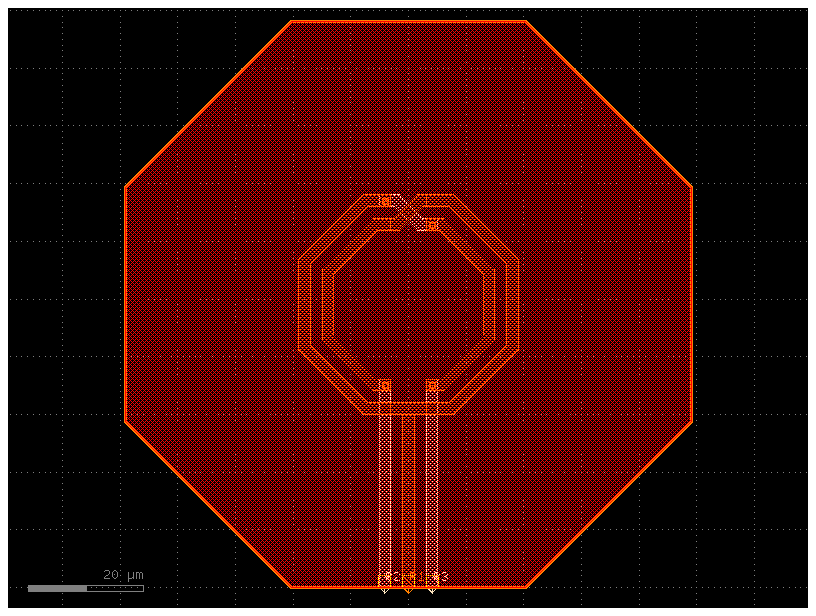

In [2]:
c = inductor3()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [3]:
# Checking the port layers.
cc.ports

["Port(self.name='P1', self.width=2000, trans=r270 *1 0,0, layer=TopMetal2pin (134/2), port_type=electrical)", "Port(self.name='P2', self.width=2000, trans=r270 *1 -4.1,0, layer=TopMetal1pin (126/2), port_type=electrical)", "Port(self.name='P3', self.width=2000, trans=r270 *1 4.1,0, layer=TopMetal1pin (126/2), port_type=electrical)"]

In [4]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-inductor3")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=5.0)

sim.add_port("P1",layer="topmetal2",offset=2.0)
sim.add_port("P2",layer="topmetal1",offset=2.0)
sim.add_port("P3",layer="topmetal1",offset=2.0)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [5]:
sim.mesh(preset="graded",margin=0.0, refined_mesh_size=0.2)

Mesh Summary
Dimensions: 38.0 x 68.0 x 23.3 µm
Nodes:      41,990
Elements:   297,002
Tetrahedra: 227,727
Edge length: 0.11 - 17.61 µm
Quality:    0.597 (min: 0.022)
SICN:       0.653 (all valid)
----------------------------------------
Volumes (4):
  - topvia2 [1]
  - SiO2 [2]
  - passive [3]
  - air [4]
Surfaces (13):
  - topmetal1_xy [5]
  - topmetal1_z [6]
  - topmetal2_xy [7]
  - topmetal2_z [8]
  - P1 [9]
  - P2 [10]
  - P3 [11]
  - SiO2__topvia2 [12]
  - SiO2__None [13]
  - SiO2__passive [14]
  - passive__None [15]
  - air__passive [16]
  - air__None [17]
----------------------------------------
Mesh:   runs/palace-sim-inductor3/palace.msh

2026-03-27 14:28:49.481 (   9.414s) [    75D01C11E080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-03-27 14:28:49.493 (   9.426s) [    75D01C11E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-03-27 14:28:49.506 (   9.439s) [    75D01C11E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-03-27 14:28:49.550 (   9.484s) [    75D01C11E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initial

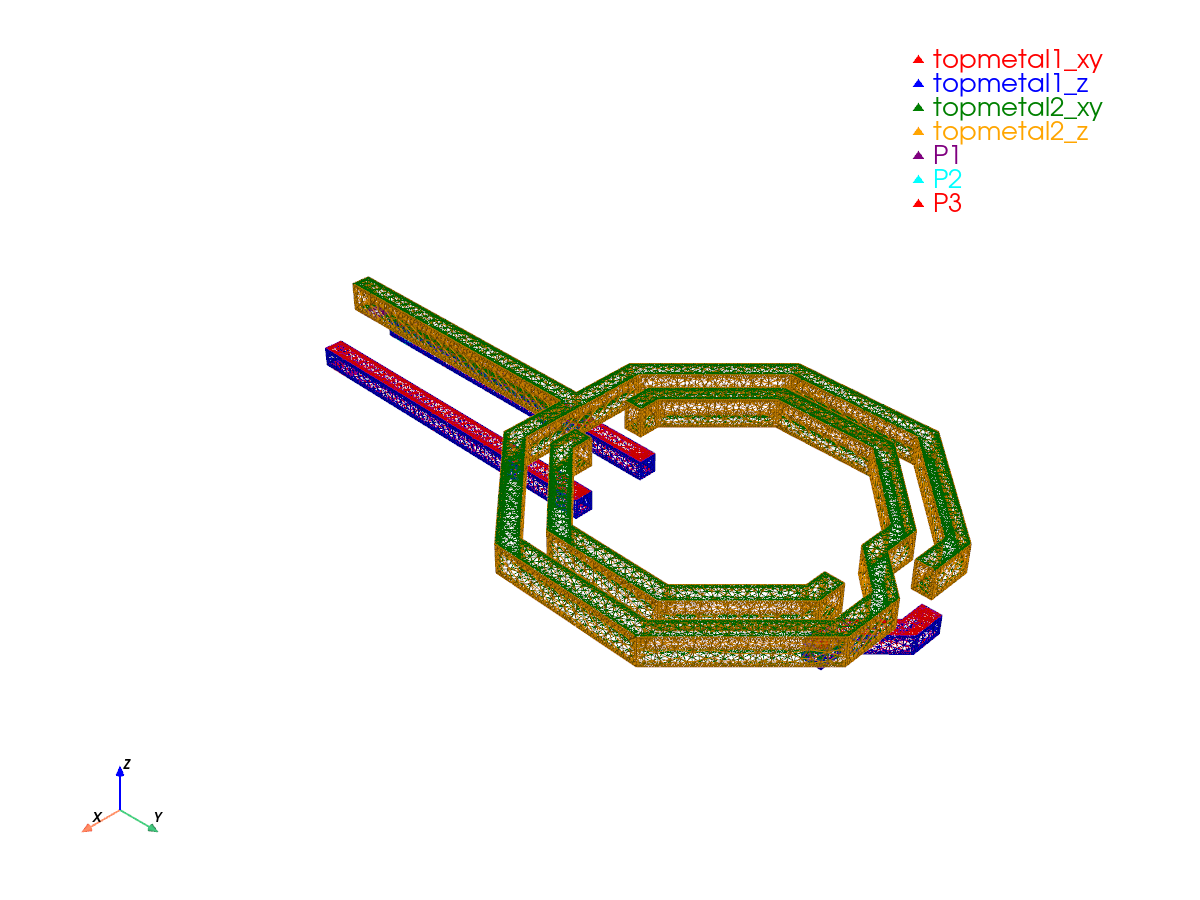

In [6]:
# TODO: investigate why geometry seems "disconnected"
sim.plot_mesh(show_groups=["metal","P"],interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-03-27 14:28:50.437 (  10.370s) [    75D01C11E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-03-27 14:28:50.447 (  10.380s) [    75D01C11E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-03-27 14:28:50.515 (  10.449s) [    75D01C11E080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


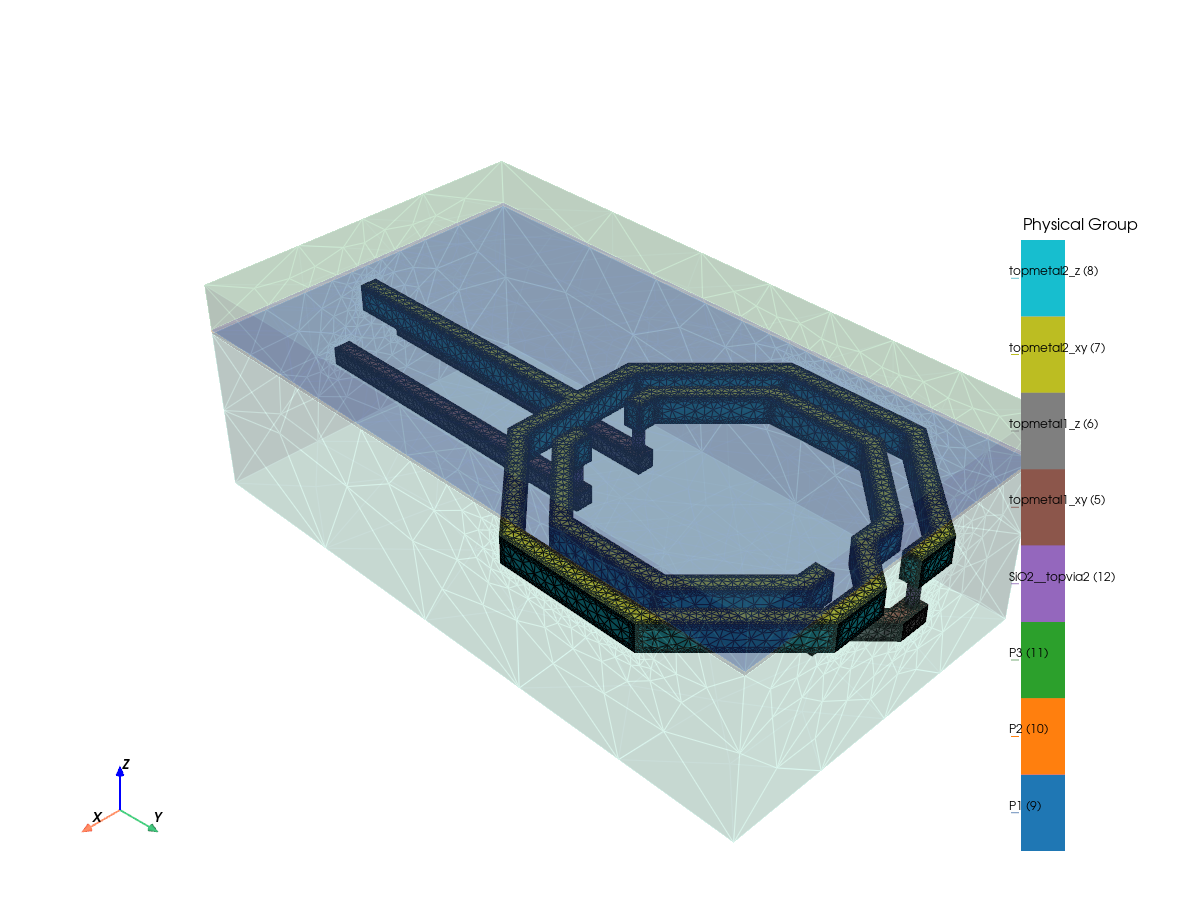

In [7]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [8]:
results = sim.run(parent_dir="runs")

  palace-584694dc  completed  23m 56s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-584694dc


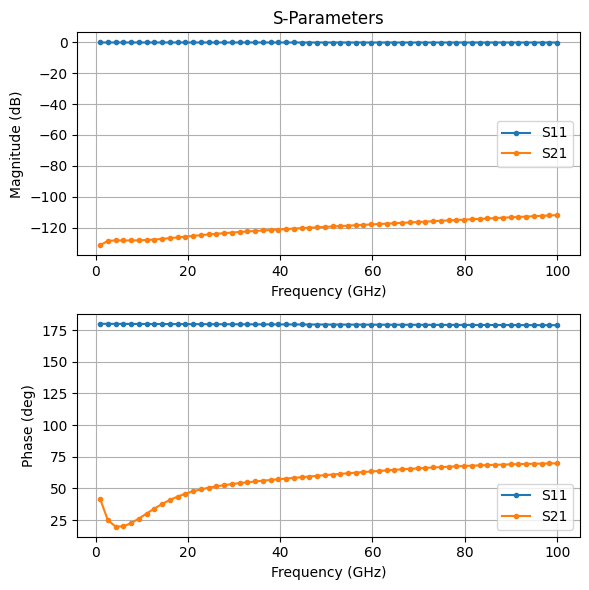

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()